# Updates

In [1]:
!pip install -U transformers
!pip install -U accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 4.0 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-m

After updating packages, restart the session and then start your notebook from imports.

# Imports

In [2]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
from IPython.display import display
import string
from wordcloud import WordCloud
import nltk
import re
import string
from bs4 import BeautifulSoup
import sklearn.metrics as metrics
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


# Load model

In [48]:
MODEL_ARGS = {
    'Name': 'microsoft/Phi-3-mini-128k-instruct',
    'DType': torch.bfloat16
}
device = "cuda" if torch.cuda.is_available() else "cpu"

In [49]:
def load_model(model_args):


    model = AutoModelForCausalLM.from_pretrained(
        model_args['Name'],
        trust_remote_code=True,
        torch_dtype= model_args['DType'],
        low_cpu_mem_usage=True,
        device_map={"": device},
    )
    tokenizer = AutoTokenizer.from_pretrained(
        model_args['Name'],
        trust_remote_code=True,
    )

    return model, tokenizer


In [50]:
llm_model, tokenizer = load_model(MODEL_ARGS)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [51]:
trainfile_path = '/train_imdb.jsonl'
augfile_path = '/aug_imdb_unlabeled.jsonl'
testfile_path = '/test_imdb.jsonl'
df_train = pd.read_json(trainfile_path, lines=True)
df_aug = pd.read_json(augfile_path, lines=True)
df_test = pd.read_json(testfile_path, lines=True)
print(len(df_test))
df_train.describe()

150


,label
count,150.000000
mean,0.553333
std,0.498813
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


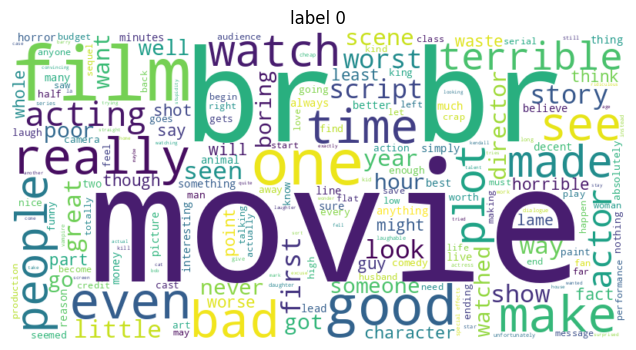

In [52]:
wordcloud = WordCloud(width = 800, height = 400, background_color ='white').generate(' '.join(df_train[df_train['label'] == 0]['text']))

plt.figure(figsize = (8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("label 0")
plt.show()

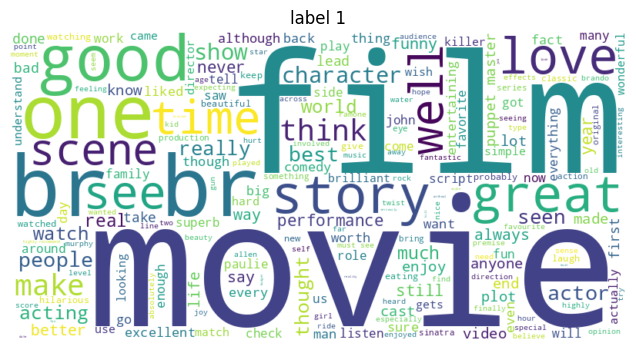

In [53]:
wordcloud = WordCloud(width = 800, height = 400, background_color ='white').generate(' '.join(df_train[df_train['label'] == 1]['text']))

plt.figure(figsize = (8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("label 1")
plt.show()

([<matplotlib.patches.Wedge at 0x7b67a71eec50>,
 [Text(-1.0845956357394322, -0.18344565117488296, 'one'),
  Text(1.0845956357394324, 0.18344565117488235, 'zero')],
 [Text(-0.5915976194942357, -0.10006126427720888, '55.3%'),
  Text(0.5915976194942358, 0.10006126427720854, '44.7%')])

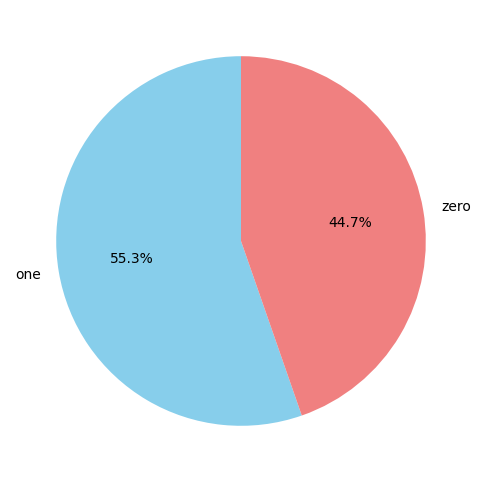

In [54]:
labels = ['one', 'zero']
count_ones = sum(df_train['label'])
count_zeros = len(df_train) - count_ones
plt.figure(figsize=(6, 6))
plt.pie([count_ones, count_zeros], labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])

<Axes: title={'center': 'distribiution of text lengh'}, xlabel='text_length'>

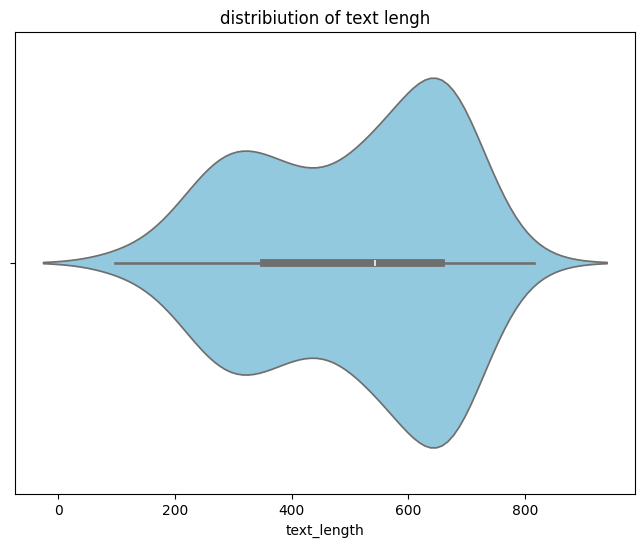

In [55]:
df = pd.DataFrame()
df['text_length'] = df_train['text'].apply(len)
plt.figure(figsize=(8, 6))
plt.title('distribiution of text lengh')
sns.violinplot(x='text_length', data=df, color='skyblue')

<Axes: title={'center': 'distribiution of text lengh with label 1'}, xlabel='text_length'>

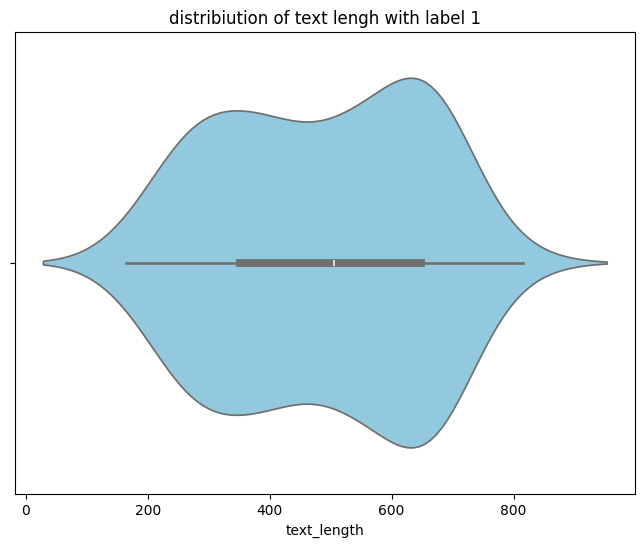

In [56]:
df = pd.DataFrame()
df['text_length'] = df_train[df_train['label']==1]['text'].apply(len)
plt.figure(figsize=(8, 6))
plt.title('distribiution of text lengh with label 1')
sns.violinplot(x='text_length', data=df, color='skyblue')

<Axes: title={'center': 'distribiution of text lengh with label 0'}, xlabel='text_length'>

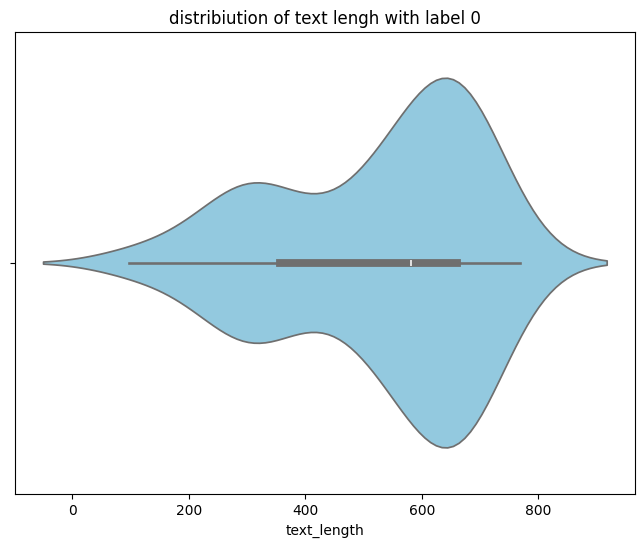

In [57]:
df = pd.DataFrame()
df['text_length'] = df_train[df_train['label']==0]['text'].apply(len)
plt.figure(figsize=(8, 6))
plt.title('distribiution of text lengh with label 0')
sns.violinplot(x='text_length', data=df, color='skyblue')

In [58]:
from sklearn.decomposition import PCA

num_elements = len(df_train['embedding'][0])
for i in range(num_elements):
    df_train[f'embedding_{i}'] = df_train['embedding'].apply(lambda arr: arr[i])
for i in range(num_elements):
    df_aug[f'embedding_{i}'] = df_aug['embedding'].apply(lambda arr: arr[i])
for i in range(num_elements):
    df_test[f'embedding_{i}'] = df_test['embedding'].apply(lambda arr: arr[i])

pca = PCA(n_components=0.9)

X_pca_train = pca.fit_transform(df_train[[f'embedding_{i}' for i in range(num_elements)]])
numOfCols = len(X_pca_train[0])
cols = ["PC" + str(i) for i in range(numOfCols)]
pca_df_train = pd.DataFrame(data=X_pca_train, columns=cols)

X_pca_aug = pca.transform(df_aug[[f'embedding_{i}' for i in range(num_elements)]])
pca_df_aug = pd.DataFrame(data=X_pca_aug, columns=cols)

X_pca_test = pca.transform(df_test[[f'embedding_{i}' for i in range(num_elements)]])
pca_df_test = pd.DataFrame(data=X_pca_test, columns=cols)

df_train = df_train.iloc[:, :3]
df_train = pd.concat([df_train, pca_df_train], axis=1)

df_aug = df_aug.iloc[:, :2]
df_aug = pd.concat([df_aug, pca_df_aug], axis=1)
df_aug.insert(1, "label", -1)

df_test = df_test.iloc[:, :3]
df_test = pd.concat([df_test, pca_df_test], axis=1)

<ipython-input-58-a1c10e94c1f5>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f'embedding_{i}'] = df_train['embedding'].apply(lambda arr: arr[i])
<ipython-input-58-a1c10e94c1f5>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f'embedding_{i}'] = df_train['embedding'].apply(lambda arr: arr[i])
<ipython-input-58-a1c10e94c1f5>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

In [59]:
import numpy as np
from sklearn.linear_model import LogisticRegression

X_train, X_val, y_train, y_val = train_test_split(pca_df_train, df_train['label'], test_size=0.2)
log_regression = LogisticRegression()
log_regression.fit(X_train, y_train)
y_pred = log_regression.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

In [60]:

probabilities = log_regression.predict_proba(pca_df_aug)[:, 1]

# Define thresholds for labeling
high_confidence_positive = 0.9
high_confidence_negative = 0.1

predicted_labels = np.full(probabilities.shape, -1)
predicted_labels[probabilities >= high_confidence_positive] = 1
predicted_labels[probabilities <= high_confidence_negative] = 0



df_aug['label'] = predicted_labels


df_add_to_train = df_aug[df_aug["label"] != -1 ]
df_aug = df_aug[df_aug["label"] == -1]
df_train = pd.concat([df_train, df_add_to_train], axis=0)


print("Number of remaining unlabeled data in augmentation set : ", len(df_aug[df_aug['label'] == -1]))


Number of remaining unlabeled data in augmentation set :  700


In [61]:
log_regression = LogisticRegression()
selected_columns_train = df_train.iloc[:, 3:]
selected_columns_aug = df_aug.iloc[:, 3:]

log_regression.fit(selected_columns_train, df_train['label'])
probabilities = log_regression.predict_proba(selected_columns_aug)[:, 1]

high_confidence_positive = 0.9
high_confidence_negative = 0.1

predicted_labels = np.full(probabilities.shape, -1)
predicted_labels[probabilities >= high_confidence_positive] = 1
predicted_labels[probabilities <= high_confidence_negative] = 0

df_aug['label'] = predicted_labels
df_add_to_train = df_aug[df_aug["label"] != -1 ]
df_aug = df_aug[df_aug["label"] == -1]
df_train = pd.concat([df_train, df_add_to_train], axis=0)

print("Number of remaining unlabeled data in augmentation set : ", len(df_aug[df_aug['label'] == -1]))


Number of remaining unlabeled data in augmentation set :  514


<ipython-input-61-978af3a14c21>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aug['label'] = predicted_labels


In [62]:
log_regression = LogisticRegression()
selected_columns_train = df_train.iloc[:, 3:]
selected_columns_aug = df_aug.iloc[:, 3:]

log_regression.fit(selected_columns_train, df_train['label'])
probabilities = log_regression.predict_proba(selected_columns_aug)[:, 1]

high_confidence_positive = 0.9
high_confidence_negative = 0.1

predicted_labels = np.full(probabilities.shape, -1)
predicted_labels[probabilities >= high_confidence_positive] = 1
predicted_labels[probabilities <= high_confidence_negative] = 0

df_aug['label'] = predicted_labels
df_add_to_train = df_aug[df_aug["label"] != -1 ]
df_aug = df_aug[df_aug["label"] == -1]
df_train = pd.concat([df_train, df_add_to_train], axis=0)

print("Number of remaining unlabeled data in augmentation set : ", len(df_aug[df_aug['label'] == -1]))



Number of remaining unlabeled data in augmentation set :  437


In [63]:
selected_columns_test = df_test.iloc[:, 3:]
y_pred = log_regression.predict(selected_columns_test)
accuracy_log = accuracy_score(df_test['label'], y_pred)
print("Accuracy on test set for Logistic Regression using label propagation: ",accuracy_log)


Accuracy on test set for Logistic Regression using label propagation:  0.78


In [64]:
embeddings = np.array(df_train['embedding'].tolist())
labels = np.array(df_train['label'])
X_train, X_val, y_train, y_val = train_test_split(embeddings, labels, test_size=0.2, random_state=42)

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    criterion='entropy',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_val = rf_model.predict(X_val)

embeddings_test = np.array(df_test['embedding'].tolist())
labels_test = np.array(df_test['label'])
y_pred_test = rf_model.predict(embeddings_test)

accuracy_val = accuracy_score(y_val, y_pred_val)
accuracy_test = accuracy_score(labels_test, y_pred_test)
print(f'Accuracy on validation set for RandomForrest estimator using Label Propagation: {accuracy_val:.2f}')
print(f'Accuracy on test set for RandomForrest estimator using Label Propagation: {accuracy_test:.2f}')

Accuracy on validation set for RandomForrest estimator using LP: 0.97
Accuracy on test set for RandomForrest estimator using LP: 0.81


In [66]:
svm_model = SVC(
    C=1.0,                  # Regularization parameter
    kernel='rbf',           # Specifies the kernel type to be used in the algorithm
    gamma='scale',          # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’
    random_state=42
)

svm_model.fit(X_train, y_train)
y_pred_val = svm_model.predict(X_val)
embeddings_test = np.array(df_test['embedding'].tolist())
labels_test = np.array(df_test['label'])
y_pred_test = svm_model.predict(embeddings_test)

accuracy_val = accuracy_score(y_val, y_pred_val)
accuracy_test = accuracy_score(labels_test, y_pred_test)
print(f'Accuracy on validation set for SVM using Label Propagation: {accuracy_val:.2f}')
print(f'Accuracy on test set for SVM using Label Propagation: {accuracy_test:.2f}')

Accuracy on validation set for SVM using LLMs: 0.99
Accuracy on test set for SVM using LLMs: 0.83


In [67]:
def generate_text(model, tokenizer, prompt, max_new_tokens = 100, do_sample=True, temperature=0.5):

    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    if do_sample:
        output_ids = model.generate(input_ids, max_new_tokens=max_new_tokens, do_sample=True, temperature=temperature)
    else:
        output_ids = model.generate(input_ids, max_new_tokens=max_new_tokens, do_sample=do_sample)

    output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    return output_text[len(prompt):]


In [68]:
def label_data(input):
  prompt = """
  Question: I think the moive was boring. Does this sentence have a positive sentiment? if so only say "1" else say "0".
  Answer:"""
  a = generate_text(
    model=llm_model,
    tokenizer=tokenizer,
    prompt=prompt,
    max_new_tokens = 2,
    temperature=1,
    )
  predicted_labels = []
  for i in range(len(input)):
    prompt = f"""
    Question: {input.iloc[i, 0]}.  Does this sentence have a positive sentiment? if so only say '1' else say '0' answer with nothing else but these.
    Answer:"""
    ans = generate_text(
      model=llm_model,
      tokenizer=tokenizer,
      prompt=prompt,
      max_new_tokens = 2,
      temperature=0.2,
    )
    predicted_labels.append(ans)
  predicted_labels = [s.strip() for s in predicted_labels]
  predicted_labels = [int(s) for s in predicted_labels]
  predicted_labels = np.array(predicted_labels)
  return predicted_labels


In [69]:
aug_labels = label_data(df_aug)
df_aug['label'] = aug_labels

In [70]:
test_labels = label_data(df_test)
accuracy_llm = accuracy_score(df_test['label'],test_labels)
print("Accuracy on test set for LLM : ", accuracy_llm)

Accuracy on test set for LLM :  0.9266666666666666


In [71]:
df_train_extended = pd.concat([df_train, df_aug], axis=0) #add the aug and train to get a bigger training set
embeddings = np.array(df_train_extended['embedding'].tolist())
labels = np.array(df_train_extended['label'])
X_train, X_val, y_train, y_val = train_test_split(embeddings, labels, test_size=0.2, random_state=42)


In [72]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    criterion='entropy',
    random_state=42
)

model.fit(X_train, y_train)
y_pred_val = model.predict(X_val)

embeddings_test = np.array(df_test['embedding'].tolist())
labels_test = np.array(df_test['label'])
y_pred_test = model.predict(embeddings_test)

accuracy_val = accuracy_score(y_val, y_pred_val)
accuracy_test = accuracy_score(labels_test, y_pred_test)
print(f'Accuracy on validation set for RandomForrest estimator using LLMs: {accuracy_val:.2f}')
print(f'Accuracy on test set for RandomForrest estimator using LLMs: {accuracy_test:.2f}')


Accuracy on validation set for RandomForrest estimator using LLMs: 0.85
Accuracy on test set for RandomForrest estimator using LLMs: 0.83


In [73]:


svm_model = SVC(
    C=1.0,                  # Regularization parameter
    kernel='rbf',           # Specifies the kernel type to be used in the algorithm
    gamma='scale',          # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’
    random_state=42
)

svm_model.fit(X_train, y_train)
y_pred_val = svm_model.predict(X_val)
embeddings_test = np.array(df_test['embedding'].tolist())
labels_test = np.array(df_test['label'])
y_pred_test = svm_model.predict(embeddings_test)

accuracy_val = accuracy_score(y_val, y_pred_val)
accuracy_test = accuracy_score(labels_test, y_pred_test)
print(f'Accuracy on validation set for SVM using LLMs: {accuracy_val:.2f}')
print(f'Accuracy on test set for SVM using LLMs: {accuracy_test:.2f}')


Accuracy on validation set for SVM using LLMs: 0.89
Accuracy on test set for SVM using LLMs: 0.81


## Q1
Strategic Sampling: Select a subset of data points for manual labeling that are representative of the overall distribution. This ensures that the labeled data covers diverse cases.

Uncertainty-Based Sampling: Prioritize labeling examples where the model is uncertain or has low confidence. These are the instances where the model’s predictions are less reliable.

Active Learning: Use active learning techniques to iteratively select data points for labeling. These methods focus on areas of uncertainty or high model error.

Domain Expertise: Involve domain experts to identify critical data points that require manual labeling.

Budget Constraints: Consider the cost and effort associated with labeling. Allocate resources wisely based on the available budget.

Balance: Strike a balance between labeled and unlabeled data. Too few labeled examples may hinder model performance, while too many may not fully exploit the unlabeled data.

### Does the Choice of Data Matter?

Yes, the choice of data for manual labeling matters significantly.
High-quality labeled data improves model accuracy and generalization.
Selecting relevant, diverse, and informative examples ensures better model performance.

## Q2
For label propagation we first trained an initial Logistic Regression model and used it to expand our labeled data. The way we did it was that for every label we predicted if the score we got from the sigmoid function was greater than 0.9 or less than 0.1 for the label being '1', we kept the prediction. Otherwise we threw it away. we then repeated this process a couple of times so that we could get more and more data.

The thing to note is that the more labels we obtain the more we could have a drop in their accuracy. Since each time more uncertain labels are being added to train data. It is important to know when to stop as a small but correctly-labeled dataset is better than a large one with a lot of noise.

## Q3
### Limitations of Label Propagation Methods

Sensitivity to Initialization:
The initial labels significantly influence the final results in label propagation.
If the initial labels are noisy or biased, the propagated labels may also be inaccurate.

Noise Sensitivity:
Label propagation is sensitive to noise and outliers in the graph.
Noisy data points can mislead the propagation process, affecting the overall quality of inferred labels.

Lack of Theoretical Guarantees:
There are no theoretical guarantees regarding the convergence or the quality of solutions obtained through label propagation.
The algorithm’s behavior may vary depending on the specific graph structure and data distribution.

### Advantages of LLMs:

Semantic Understanding: LLMs capture rich semantic information from text data.

Robustness: LLMs are less sensitive to noisy data compared to traditional label propagation methods.

Generalization: LLMs generalize well across different domains and languages.

## Q4
### How Language Models Work

A language model is a probabilistic model of natural language. It predicts the likelihood of a word or sequence of words given the context.
LLMs learn from vast text data and estimate the probabilities of words and sequences.
They use this information to predict the next word in a sentence based on the preceding context.
LLMs handle rich context, making them suitable for tasks like text generation, speech recognition, and more.

### Advantages of Large Language Models (LLMs)
Generative Applications:
LLMs power chatbots, text generation, and image-to-video generators.
They automate content creation, analyze large datasets, and answer questions.
Rich context handling enables practical generative AI.

Scalability and Versatility:
LLMs are trained on expansive datasets and can scale with model size.
Fine-tuning allows adaptation to newer information and evolving language patterns.

Ease of Use and Managed Services:
Cloud-based LLMs offer APIs, tools, and frameworks for easy development.
Managed services handle infrastructure setup, maintenance, and security.

### Limitations of Large Language Models

Resource Intensive:
Training and deployment demand substantial computing resources.
Energy consumption and environmental impact are concerns.

Ethical and Bias Challenges:
LLMs may perpetuate biases present in training data.
Generated content can inadvertently spread misinformation.

Lack of World Knowledge:
LLMs lack intrinsic knowledge beyond language patterns.

## Q5 : done

## Q6
Will explain in person :P